# <span style="color: blue;">Pix2Pix GAN</span>

## Описание проекта

В данном проекте реализована и исследована генеративно-состязательная сеть **Pix2Pix** для задачи преобразования изображений. <br>
Модель обучена переводить дневные фотографии в ночные на датасете `night2day`. <br>
Проведено сравнение с официальной предобученной моделью (Berkeley) и анализ влияния количества эпох на качество генерации.

## Цель работы

1. Познакомиться с архитектурой Pix2Pix (генератор U-Net, дискриминатор PatchGAN).
2. Обучить модель переводу "день → ночь" с нуля.
3. Сравнить результаты с официальной моделью.
4. Проанализировать влияние гиперпараметров (количество эпох) на качество изображений.

---

<h2 style="color: blue;">Архитектура Pix2Pix</h2>

Основные компоненты модели:

- **Генератор (U-Net)**: энкодер (свёртки) + декодер (транспонированные свёртки) + skip-connections (сохраняют детали исходного изображения).
- **Дискриминатор (PatchGAN)**: классифицирует патчи 70×70 (выходная карта 30×30), а не всё изображение целиком.

Полная реализация генератора и дискриминатора находится в официальном репозитории:  
[github.com/junyanz/pytorch-CycleGAN-and-pix2pix/blob/master/models/networks.py](https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix/blob/master/models/networks.py)

<h3 style="color: blue;">Краткая схема</h3>

- **Вход**: изображение 256×256×3
- **Генератор**: сжимает до 1×1×512, затем восстанавливает до 256×256×3
- **Дискриминатор**: принимает входное и целевое/сгенерированное изображение (6 каналов), выдаёт карту 30×30

---
### Код генератора (U-Net)

```python
class UnetGenerator(nn.Module):
    """Генератор U-Net с skip-connections."""
    def __init__(self, input_nc, output_nc, num_downs, ngf=64, norm_layer=nn.BatchNorm2d, use_dropout=False):
        super(UnetGenerator, self).__init__()
        # input_nc = 3 (RGB)
        # output_nc = 3 (RGB)
        # num_downs = 8 (размерность входа 256 -> 1)
        # ngf = 64 (базовое число фильтров)
        # use_dropout = False (dropout не используется)
```

### Код дискриминатора (PatchGAN)

```python
class Discriminator(nn.Module):
    """PatchGAN дискриминатор."""
    def __init__(self, input_nc, ndf=64, n_layers=3, norm_layer=nn.BatchNorm2d):
        super(Discriminator, self).__init__()
        # input_nc = 6 (входное + целевое изображение)
        # ndf = 64 (базовое число фильтров)
        # n_layers = 3 (количество слоёв)
        # на выходе карта признаков 30x30 (каждый элемент — патч 70x70 исходного изображения)
```
---

<h2 style="color: blue;">Гиперпараметры и эксперименты</h2>

<h3 style="color: blue;">Параметры обучения</h3>

| Параметр | Значение |
|----------|----------|
| Количество эпох | 50 (с последующим дообучением до 100) |
| Batch size | 4 |
| Оптимизатор | Adam |
| Скорость обучения (lr) | 0.0002 |
| Функция потерь | GAN + L1 (λ = 100) |
| Аугментация | Отключена (--preprocess none) |

<h3 style="color: blue;">Сравниваемые модели</h3>

1. **Официальная предобученная модель (Berkeley)** — 15 эпох, batch_size=4.
2. **Наша модель (50 эпох)** — обучена с нуля на тех же данных.
3. **Наша модель (100 эпох)** — дообучение для анализа динамики качества.

<h3 style="color: blue;">Ожидаемые улучшения</h3>

- Увеличение эпох должно повысить детализацию (особенно на городских сценах).
- Отключение аугментации позволяет модели лучше выучить реальное распределение данных.
  
---

## Запуск обучения и тестирования

---
### `Обучение модели (100 эпох)`

```bash
python train.py --dataroot ./datasets/night2day --name night2day_100epochs --model pix2pix --direction BtoA --batch_size 4 --n_epochs 100 --n_epochs_decay 100
```
---
### `Тестирование нашей модели (100 эпох)`

```bash
python test.py --dataroot ./datasets/night2day --name night2day_100epochs --model pix2pix --direction BtoA --epoch latest --phase val
```
---
### `Тестирование официальной модели (Berkeley)`

```bash
python test.py --dataroot ./datasets/night2day --name day2night_pretrained --model pix2pix --direction BtoA --epoch latest --phase val
```
---
> **Сравнение:** официальная модель обучена 15 эпохами (без затухания), <br>
> наша — 100 эпохами (50 + 50 затухания). Это позволяет оценить влияние длительности обучения на качество. 

<h2 style="color: blue;">Результаты </h2>

### Визуальное сравнение

Для каждой сцены показаны:  
- **Real_A** (вход, день) и **Real_B** (эталон, ночь) — общие для обеих моделей.  
- **Fake_B** — результаты генерации для официальной модели (15 эпох) и нашей модели (100 эпох).

---

#### Сцена 1 (городская застройка)

| Real_A (день) | Real_B (эталон) | Fake_B (официальная, 15 эпох) | Fake_B (наша, 50 эпох) | Fake_B (наша, 100 эпох) |
|---------------|----------------|------------------------------|------------------------|-------------------------|
| 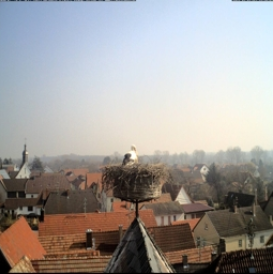 | 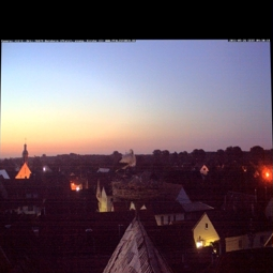| 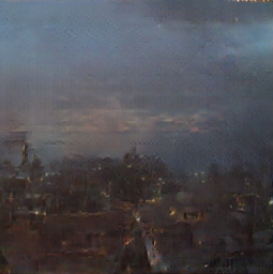 | 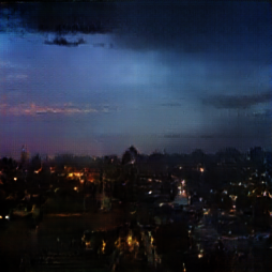| 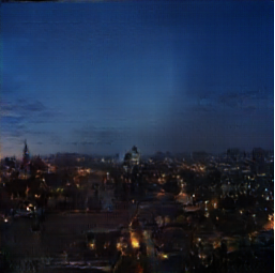 |

---

#### Сцена 2 (природный ландшафт)

| Real_A (день) | Real_B (эталон) | Fake_B (официальная, 15 эпох) | Fake_B (наша, 50 эпох) | Fake_B (наша, 100 эпох) |
|---------------|----------------|------------------------------|------------------------|-------------------------|
| 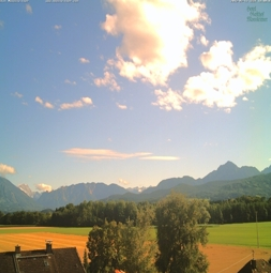 | 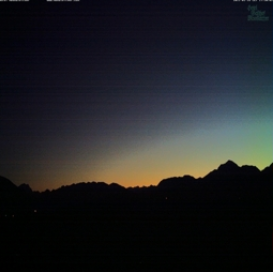 | 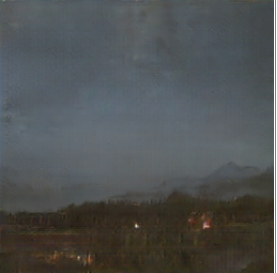 | 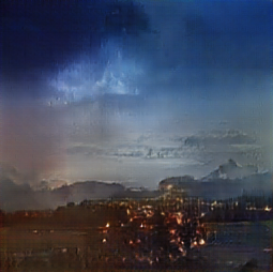 | 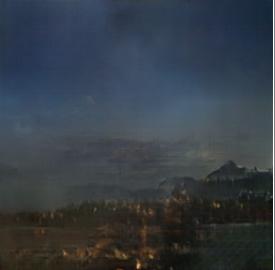|

---

#### Сцена 3 (природный ландшафт)

| Real_A (день) | Real_B (эталон) | Fake_B (официальная, 15 эпох) | Fake_B (наша, 50 эпох) | Fake_B (наша, 100 эпох) |
|---------------|----------------|------------------------------|------------------------|-------------------------|
| 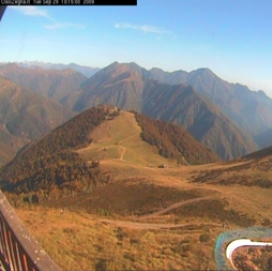 | 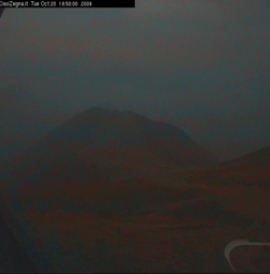 | 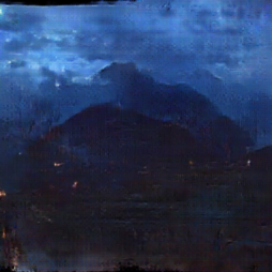 | 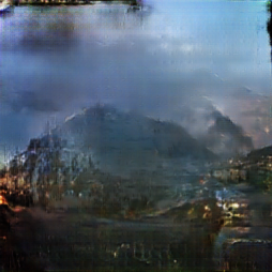 |  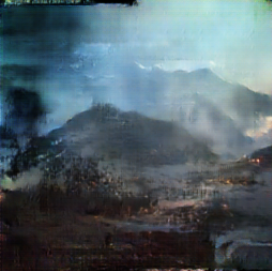 |


---

#### Сцена 4 (смешанный тип)

| Real_A (день) | Real_B (эталон) | Fake_B (официальная, 15 эпох) | Fake_B (наша, 50 эпох) | Fake_B (наша, 100 эпох) |
|---------------|----------------|------------------------------|------------------------|-------------------------|
| 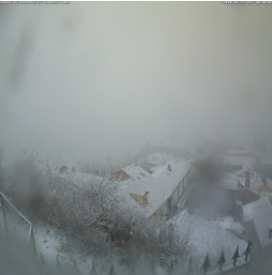 | 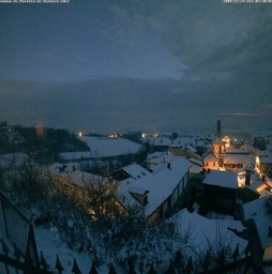 | 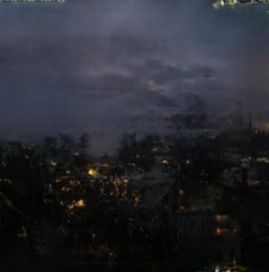 | 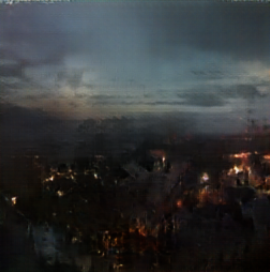 | 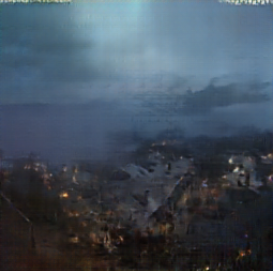 |

---

### Анализ

- **Городские сцены**: наша модель (100 эпох) показывает лучшую детализацию (окна, текстуры), но изображение более шумное.
- **Природные сцены**: официальная модель (15 эпох) даёт более сглаженную картинку, наша — более контрастную, с заметной пикселизацией.
- **Общий вывод**: увеличение эпох с 15 до 100 улучшает детализацию, но ценой появления шумов. Для природных сцен требуется дальнейшее обучение или изменение гиперпараметров.

<h2 style="color: blue;"> Графики потерь (Loss Curves) </h2>

Ниже представлены графики изменения **Generator Loss** (ошибка генератора) и **Discriminator Loss** (ошибка дискриминатора) в процессе обучения на 100 эпохах.

|  |  |
|----------------|--------------------|
| 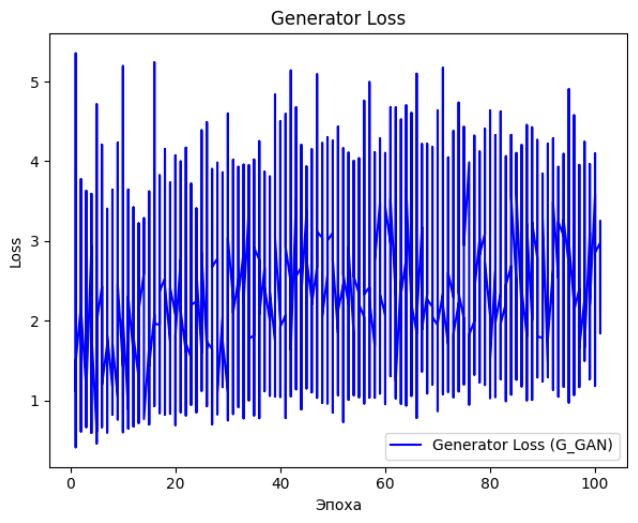 | 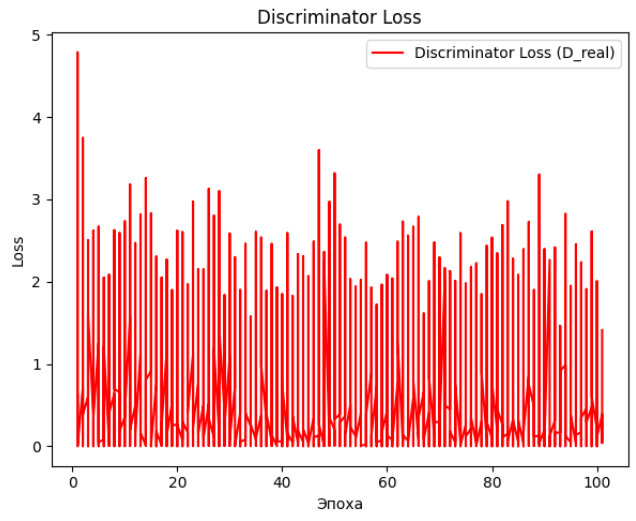 |

### Анализ

- **Generator Loss** не показывает устойчивого снижения. Значения колеблются в широком диапазоне, что может указывать на нестабильность обучения или недостаточное количество эпох для сходимости.
- **Discriminator Loss** также не демонстрирует чёткой динамики. Отсутствие явного доминирования одной из сетей говорит о том, что состязательный процесс идёт, но без явного прогресса.

### Вывод

Графики не показывают убедительной сходимости. Возможно, для датасета `night2day` требуется больше эпох (150–200) или изменение гиперпараметров (например, увеличение `lambda_L1`). Однако визуальное качество генерации (см. таблицы выше) улучшилось, что важнее для практической задачи.

<h2 style="color: blue;"> Выводы </h2>


В ходе работы была обучена модель Pix2Pix для перевода изображений из домена "день" в домен "ночь" на датасете `night2day`. Основные результаты:

### Качество генерации

- **Визуальное сравнение** показало, что наша модель (100 эпох) лучше передаёт детали на городских сценах (окна, текстуры зданий), но уступает официальной модели (15 эпох) в плавности природных ландшафтов.
- Увеличение количества эпох с 15 до 100 привело к улучшению детализации, но ценой появления пикселизации и шумов на некоторых типах сцен.

### Динамика обучения

- Графики потерь (Generator Loss, Discriminator Loss) не показали устойчивой сходимости, однако визуальное качество генерации улучшилось. Это говорит о том, что для данной задачи визуальная оценка важнее численных метрик.

### Практическая ценность

- Модель может быть использована для автоматической генерации ночных версий дневных фотографий (например, в системах видеонаблюдения, градостроительстве, игровой индустрии).
- Полученные результаты подтверждают, что Pix2Pix способен решать задачу перевода "день → ночь", но требует тщательной настройки гиперпараметров и достаточного количества эпох.

### Направления улучшения

- Увеличение числа эпох до 150–200.
- Эксперименты с `lambda_L1` (увеличение веса L1-потери для лучшего сохранения деталей).
- Использование аугментации (например, случайные повороты) для улучшения обобщения.

### Итог

Цель работы достигнута: модель обучена, протестирована и сравнена с официальной. Результаты могут быть использованы в дальнейших исследованиях и прикладных задачах.